In [1]:
!pip install -q monai nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.7 MB/s eta 0:00:00


In [2]:
!pip install -q monai nibabel

import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import scipy.ndimage as ndi

from monai.networks.nets import UNet
from monai.transforms import *
from monai.data import Dataset, DataLoader

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-03-29 10:44:49.899834: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774781090.105817      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774781090.172390      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774781090.668430      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774781090.668474      24 computation_placer.cc:1

In [3]:
MODEL_PATH = "/kaggle/input/models/vanshoberoi03/seg-model/pytorch/default/1/model.pth"
IMG_DIR = "/kaggle/input/datasets/vanshoberoi03/heart-dataset/heart_dataset/images"
MASK_DIR = "/kaggle/input/datasets/vanshoberoi03/heart-dataset/heart_dataset/masks"

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [5]:
image_files = sorted([f for f in os.listdir(IMG_DIR) if f.endswith(".nii")])

test_files = [
    {
        "image": os.path.join(IMG_DIR, f),
        "label": os.path.join(MASK_DIR, f)
    }
    for f in image_files
]

print("Total samples:", len(test_files))

Total samples: 50


In [6]:
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ResizeD(keys=["image", "label"], spatial_size=(128,128,128)),

    ScaleIntensityRanged(
        keys=["image"],
        a_min=-100,
        a_max=400,
        b_min=0.0,
        b_max=1.0,
        clip=True
    )
])

In [7]:
test_ds = Dataset(test_files, transform=val_transforms)
test_loader = DataLoader(test_ds, batch_size=1)

In [8]:
def largest_component(mask):
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = ndi.sum(mask, labeled, range(1, num + 1))
    largest = (sizes.argmax() + 1)
    return (labeled == largest).astype(mask.dtype)

In [9]:
best_threshold = 0.4

dice_scores = []
times = []

with torch.no_grad():
    for batch in test_loader:
        img = batch["image"].to(device)
        mask = batch["label"].to(device)

        start = time.time()

        pred = torch.sigmoid(model(img))
        pred = (pred > best_threshold).float()

        pred_np = pred.cpu().numpy()[0,0]
        pred_np = largest_component(pred_np)

        end = time.time()

        times.append(end - start)

        pred = torch.tensor(pred_np).unsqueeze(0).unsqueeze(0).to(device)

        intersection = (pred * mask).sum()
        dice = (2 * intersection) / (pred.sum() + mask.sum() + 1e-8)

        dice_scores.append(dice.item())

print("Final Test Dice:", np.mean(dice_scores))
print("Avg Inference Time:", np.mean(times), "seconds")

Final Test Dice: 0.9417707586288452
Avg Inference Time: 0.09572740554809571 seconds


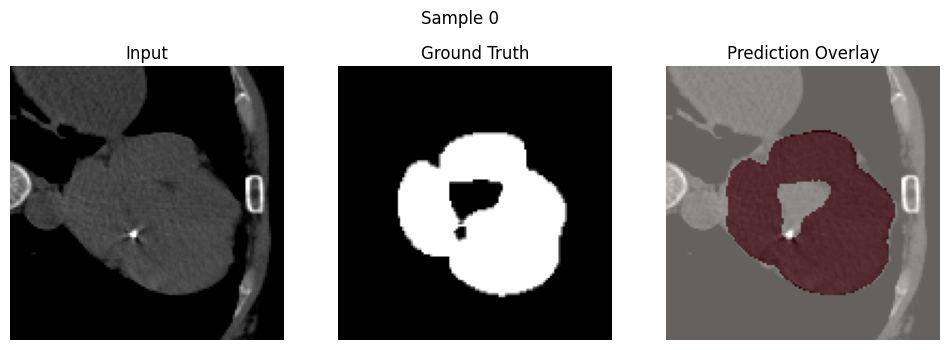

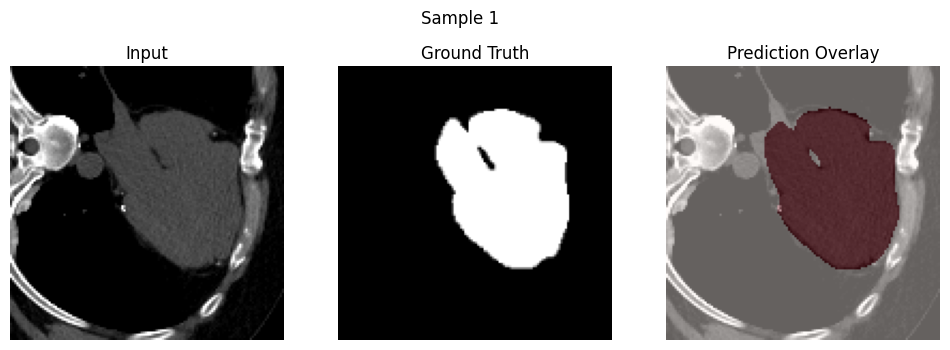

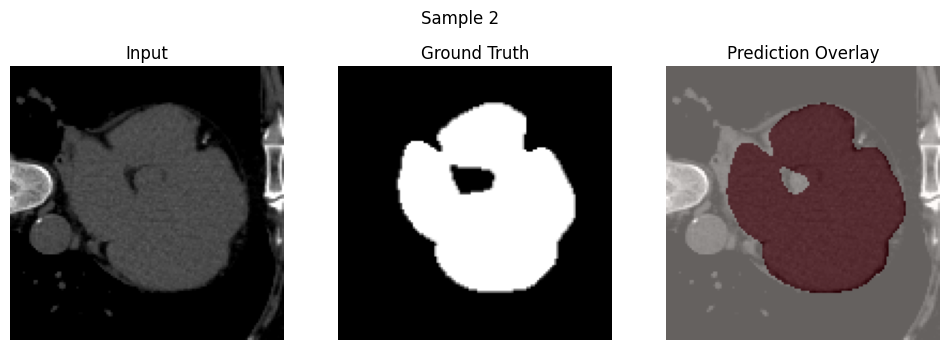

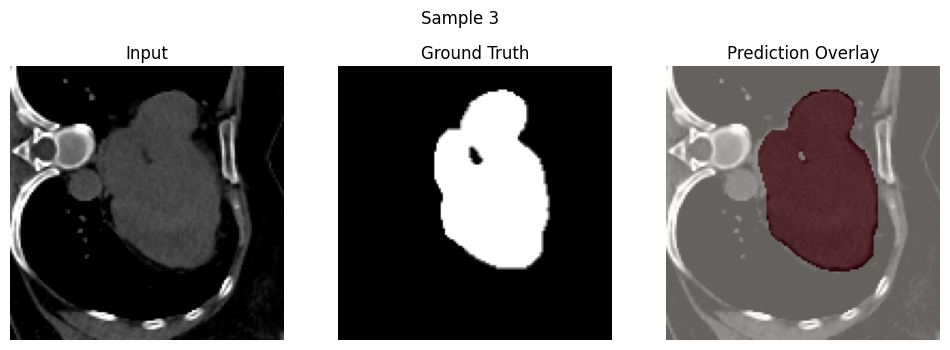

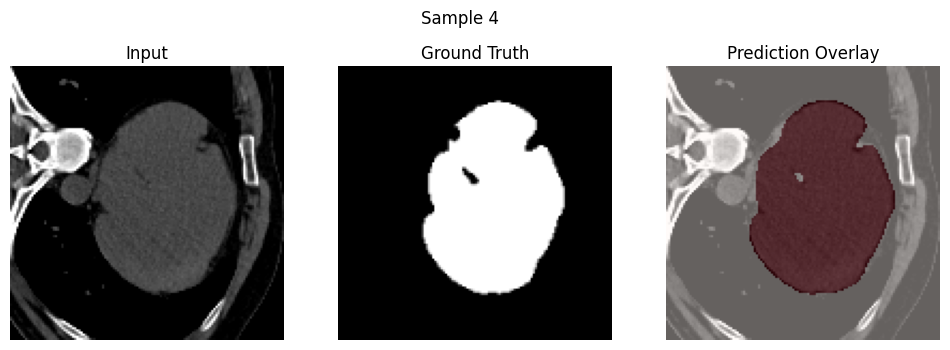

In [10]:
def visualize_batch(batch, idx):
    img = batch["image"].to(device)
    mask = batch["label"].to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(img))
        pred = (pred > best_threshold).float()

    img_np = img.cpu().numpy()[0,0]
    mask_np = mask.cpu().numpy()[0,0]
    pred_np = pred.cpu().numpy()[0,0]

    slice_idx = img_np.shape[-1] // 2

    plt.figure(figsize=(12,4))
    plt.suptitle(f"Sample {idx}")

    plt.subplot(1,3,1)
    plt.imshow(img_np[:,:,slice_idx], cmap='gray')
    plt.title("Input")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(mask_np[:,:,slice_idx], cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(img_np[:,:,slice_idx], cmap='gray')
    plt.imshow(pred_np[:,:,slice_idx], alpha=0.4, cmap='Reds')
    plt.title("Prediction Overlay")
    plt.axis('off')

    plt.show()


for idx, batch in enumerate(test_loader):
    visualize_batch(batch, idx)
    if idx == 4:
        break